# Aplicando o Pacote no Prop99

In [1]:
# Carregando pacotes
import sys
import os
import pandas as pd
import numpy as np

# Pega o caminho absoluto da pasta pai (pysdid) e adiciona ao path do Python
sys.path.append(os.path.abspath('..'))

# Agora você pode importar a sua biblioteca normalmente
import syndid


In [2]:
# carregando dados
path = "proposition99.csv"
df = pd.read_csv(path, sep=";")

df.columns = ['estado', 'ano', 'cigarros_per_capita', "tratado"]
df['tratado'] = ((df['estado'] == 'California') & (df['ano'] >= 1989)).astype(int)

print(df.head())
df.info()

        estado   ano  cigarros_per_capita  tratado
0      Alabama  1970            89.800003        0
1     Arkansas  1970           100.300003        0
2     Colorado  1970           124.800003        0
3  Connecticut  1970           120.000000        0
4     Delaware  1970           155.000000        0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   estado               1209 non-null   object 
 1   ano                  1209 non-null   int64  
 2   cigarros_per_capita  1209 non-null   float64
 3   tratado              1209 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 37.9+ KB


In [3]:
prop99 = syndid.SyntheticDID(df,"estado", "ano", ["California"], 1989, "cigarros_per_capita")
prop99.fit()


--- Placebo Results ---
Original ATT: -15.6042
Valid Placebos: 38/38
P-Valor: 0.0263


In [4]:
prop99.summary()

                 Synthetic Difference-in-Differences Results                  
Dep. Variable:       Y                    No. Observations:                 39
Estimator:           SDID                 No. Treated:                       1
Inference:           Placebo Test         No. Controls:                     38
------------------------------------------------------------------------------
                   coef    std err          z      P>|z|     [0.025     0.975]
------------------------------------------------------------------------------
ATT            -15.6042     9.4943     -1.644      0.026   -34.2127     3.0042


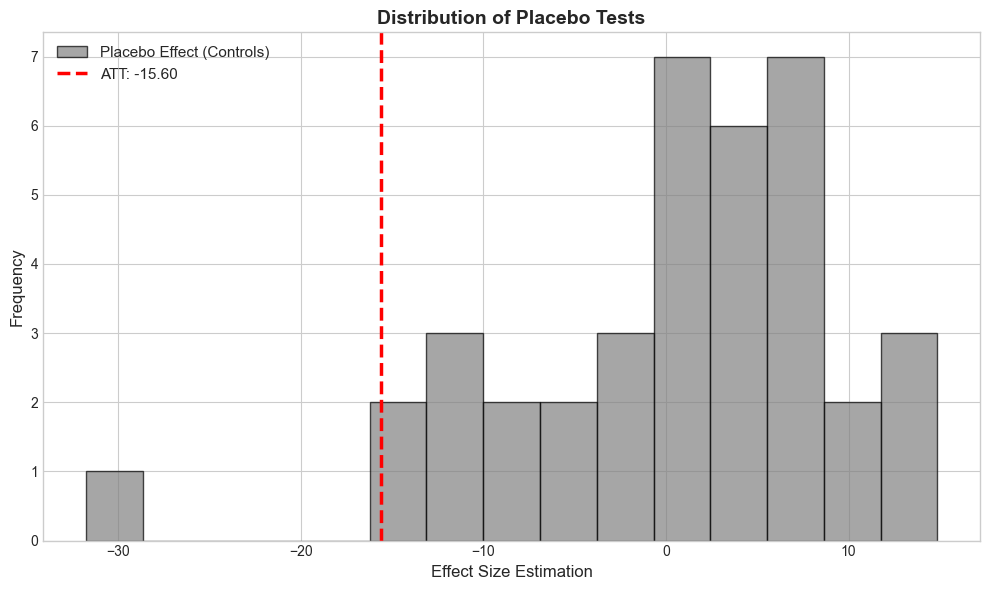

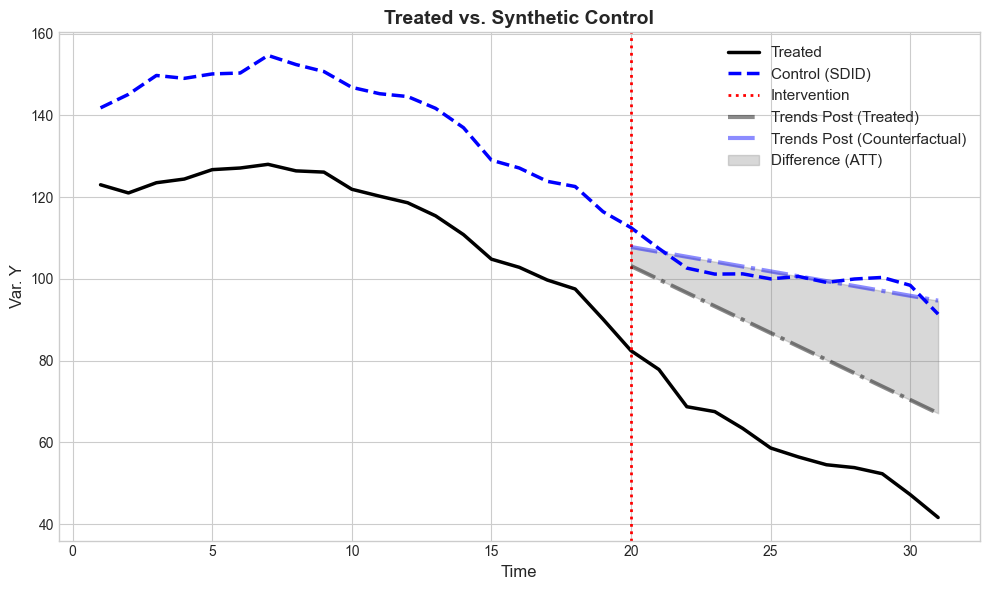

In [5]:
prop99.plot_placebos()
prop99.plot_trends()